**Scenario**: prediction of median house value in California districts using census-style features.

We’ll use the California Housing dataset from scikit-learn. It is real tabular data with eight features.


The target is:

**Price** which is the median house value, measured in units of $100,000. For example, a prediction of 2.4 means about $240,000.


**Project Goal**

Training a gradient boosting model that learns different feature patterns and predicts the Price of housing in California.


** These features are:**


MedInc      median income

HouseAge    median house age

AveRooms    average rooms

AveBedrms   average bedrooms

Population  population

AveOccup    average occupancy

Latitude    latitude

Longitude   longitude


A. Validate the resuls and compare it with basline model.

B. Find the best model parameters and visulize the scatter of the predicted vs actual data.

C. Calculate and visualize the most importanc features of this model.




In [2]:
import os

os.cpu_count()

2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [4]:
df = X.copy()
df['Price'] = y

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:

# ------------------------------------------------------------
# 2. Train/test split
# ------------------------------------------------------------


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('size of the trained data', X_train.shape)
print('size of the test data', X_test.shape)


size of the trained data (14448, 8)
size of the test data (6192, 8)


In [8]:
# ------------------------------------------------------------
# 3. Baseline Model
# ------------------------------------------------------------

# This is the average of the target values as the most basic model

baseline = DummyRegressor(strategy = 'mean')
baseline.fit(X_train, y_train)
baseline_predict = baseline.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_predict)
baseline_mse = mean_squared_error(y_test, baseline_predict)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_predict)

print('Errors of the Baseline Model:')
print('MAE = ', baseline_mae)
print('RMSE = ', baseline_rmse)
print('R2 = ', baseline_r2)


Errors of the Baseline Model:
MAE =  0.906200749174264
RMSE =  1.1456636798696462
R2 =  -3.930972139576383e-06


In [9]:
# ------------------------------------------------------------
# 4. Gradient Boosting Model
# ------------------------------------------------------------
# Now, we test the Gradient Boosting Model and compare it with the B

gbr = HistGradientBoostingRegressor(
    learning_rate=0.05, # the step in opposite direction of the gradient for each iteration
    max_iter=400, # the maximum number of trees in the forest
    max_leaf_nodes=31,  # the maximum number of leaves in a tree
    min_samples_leaf=20, # the minimum number of samples at each leave
    l2_regularization=0.1, # the calculated error type
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_predict = gbr.predict(X_test)
gbr_mae = mean_absolute_error(gbr_predict, y_test)
gbr_mse = mean_squared_error(gbr_predict, y_test)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(gbr_predict, y_test)

print('Errors of the Gradient Boosting Model:')
print('MAE = ', gbr_mae)
print('RMSE = ', gbr_rmse)
print('R2 = ', gbr_r2)

Errors of the Gradient Boosting Model:
MAE =  0.29845264603617977
RMSE =  0.44966685705983334
R2 =  0.8147697276964303


In [10]:
# ------------------------------------------------------------
# 5. Cross Validation
# ------------------------------------------------------------

# To check the general capability of the model, the cross validation of the model should be calculated

from sklearn.model_selection import cross_validate

cv_results = cross_validate(gbr, X_train, y_train, cv = 5, scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2'])


In [11]:
cv_results.items()

dict_items([('fit_time', array([4.47156405, 2.39350319, 1.61007953, 1.10921049, 1.21937585])), ('score_time', array([0.27758789, 0.22309256, 0.09140205, 0.09950852, 0.10843515])), ('test_neg_mean_absolute_error', array([-0.31279915, -0.30459618, -0.30136899, -0.30938777, -0.31216596])), ('test_neg_mean_squared_error', array([-0.22384091, -0.21983595, -0.21265575, -0.21735472, -0.22282956])), ('test_neg_root_mean_squared_error', array([-0.47311829, -0.46886667, -0.46114613, -0.46621317, -0.47204826])), ('test_r2', array([0.83857206, 0.82594019, 0.84352147, 0.83615049, 0.83622538]))])

In [12]:
print('CV_MAE : ', -cv_results['test_neg_mean_absolute_error'].mean())
print('CV_RMSE : ', -cv_results['test_neg_root_mean_squared_error'].mean())
print('CV_R2 : ', cv_results['test_r2'].mean())


CV_MAE :  0.3080636102005423
CV_RMSE :  0.46827850436117097
CV_R2 :  0.8360819190146745


1. The considarable difference between MSE and MAE is indicative of the abundant outliers in the dataset.
2. the r2 score shows that 0.83 of the variations in the Price could be explained by the evaluated features.

In [13]:
# ------------------------------------------------------------
# 5. Grid Search Cross Validation
# ------------------------------------------------------------

# Now, it's time to consider different hyper parameters and find an optimized model

hyper_parameters = {
    'learning_rate': [0.01, 0.05],
    'max_iter': [200],
    'max_leaf_nodes': [31, 35],
    'min_samples_leaf': [20],
    'l2_regularization': [0.1]
}

grid_search = GridSearchCV(
    estimator = HistGradientBoostingRegressor(random_state = 42),
    param_grid = hyper_parameters,
    cv = 3,
    scoring = 'r2',
    verbose = 1,
    n_jobs = -1
)

In [14]:
grid_search.fit(X_train, y_train)




Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=HistGradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'l2_regularization': [0.1],
                         'learning_rate': [0.01, 0.05], 'max_iter': [200],
                         'max_leaf_nodes': [31, 35], 'min_samples_leaf': [20]},
             scoring='r2', verbose=1)

In [15]:
print('\n Best Parameters:')
print(grid_search.best_params_)

print('\n Best score: ')
print(grid_search.best_score_)



 Best Parameters:
{'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 35, 'min_samples_leaf': 20}

 Best score: 
0.8295974573155901


In [16]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
best_preds= best_model.predict(X_test)

print('\n Best Model Errors:')
print('best_MAE = ', mean_absolute_error(y_test, best_preds))
print('best_RMSE = ', np.sqrt(mean_squared_error(y_test, best_preds)))
print('best_R2 = ', r2_score(y_test, best_preds))


 Best Model Errors:
best_MAE =  0.30764500445456583
best_RMSE =  0.45868954712330023
best_R2 =  0.8397031074420962


In [17]:

# ------------------------------------------------------------
# 8. Feature importance using permutation importance
# ------------------------------------------------------------

# In this section, each feature is shuffled randomly and the variations of the errors is evaluated.
# If the changes are significant, that means the considered feature is an important feature of the model.
# Otherwise, the considered feature does not matter

importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance.importances_mean
}).sort_values("importance", ascending=False)

print("\nPermutation importance:")
print(importance_df)




Permutation importance:
      feature  importance
6    Latitude    0.811866
7   Longitude    0.652535
0      MedInc    0.577568
5    AveOccup    0.159833
1    HouseAge    0.041881
2    AveRooms    0.030066
3   AveBedrms    0.006391
4  Population    0.006335


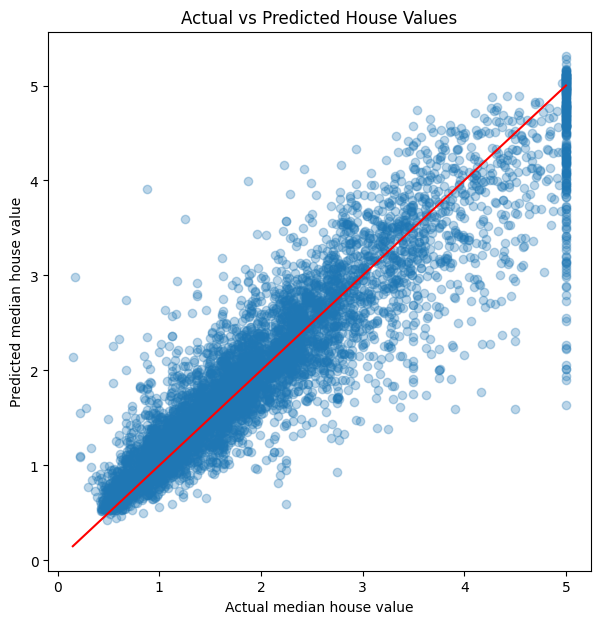

In [18]:
# ------------------------------------------------------------
# 9. Plot predicted vs actual
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual median house value")
plt.ylabel("Predicted median house value")
plt.title("Actual vs Predicted House Values")
plt.show()



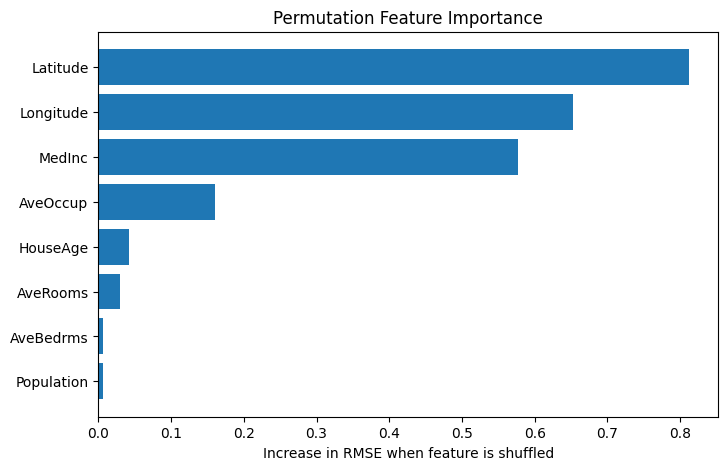

In [19]:
# ------------------------------------------------------------
# 10. Plot feature importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.show()